# Model CEF-phonon coupling of LYbS

Allen Scheie

July 2026

In [1]:
## --- import libraries ------
import numpy as np
import matplotlib.pyplot as plt
import PyCrystalField.PyCrystalField as cef

from matplotlib.colors import Normalize
from copy import deepcopy

 *******************************************************
 *                PyCrystalField 2.4.1                *
 *  Please cite  J. Appl. Cryst. (2021). 54, 356-362   * 
 *    <https://doi.org/10.1107/S160057672001554X>      *
 *******************************************************



In [2]:
ciffile = 'LiYbS2_DFT-relaxed.cif'
YbLig0, Yb = cef.importCIF(ciffile, 'Yb', NumIonNeighbors=2) # Generates point charge model

unit cell: 3.842 3.842 18.54 90.0 90.0 120.0
Importing atoms
   12 atoms added
.cif import complete.
Central ion: Yb3+ at [0.0, 0.0, 0.0]
    AAAH! There is a super-close atom. Removing it...
 Nearest ligand: S2-
 Next Nearest ligand: Li1+
   Identified 6 S2- ligands.
   Identified 6 Li1+ ligands.
   Found 3 fold axis about [0. 0. 2.]
   Found mirror plane: [1. 0. 0.]

  Axes for point charge model (in ABC space):
        X axis = [-0.5 -1.   0. ] 
        Y axis = [1. 0. 0.] 
        Z axis = [0. 0. 1.] 

   Creating a point charge model...
B_2 0  =  -0.63537743
B_2 1  =  1e-08
B_2 2  =  -0.0
B_4 0  =  0.01084168
B_4 1  =  -0.0
B_4 2  =  -0.0
B_4 3  =  -0.31805999
B_4 4  =  -0.0
B_6 0  =  4.031e-05
B_6 1  =  -0.0
B_6 2  =  0.0
B_6 3  =  0.00086814
B_6 4  =  0.0
B_6 5  =  -0.0
B_6 6  =  0.00038544


In [3]:
### --- Now we adjust the effective charges by hand so they are close to the data
LigandCharges = [-3.5,1]  #[-1.95,1]
symequivlabels = [0]*6 + [1]*6  ## This must be set by hand
Yb = YbLig0.PointChargeModel(symequiv = symequivlabels, LigandCharge=LigandCharges)

B_2 0  =  -0.33098893
B_2 1  =  2e-08
B_2 2  =  -0.0
B_4 0  =  0.01938993
B_4 1  =  -0.0
B_4 2  =  -0.0
B_4 3  =  -0.54450978
B_4 4  =  -0.0
B_6 0  =  6.72e-05
B_6 1  =  -0.0
B_6 2  =  0.0
B_6 3  =  0.00144502
B_6 4  =  0.0
B_6 5  =  -0.0
B_6 6  =  0.00067686


## Now import DFT results

In [ ]:
### Import the DFT results, create a new DFT_phonon_CEF object
 ## from the mesh.yaml file and the Ligands object. 
dftyamlfile = 'mesh.yaml'
LYS_dftcef = cef.DFT_phonon_CEF(dftyamlfile, YbLig0)

There are 36 phonon modes
 and 28 wavevectors
central ion index: 0 {'symbol': 'Yb', 'coordinates': [2.3613475e-08, 4.2398807e-08, 5.57565e-10], 'mass': 173.054}


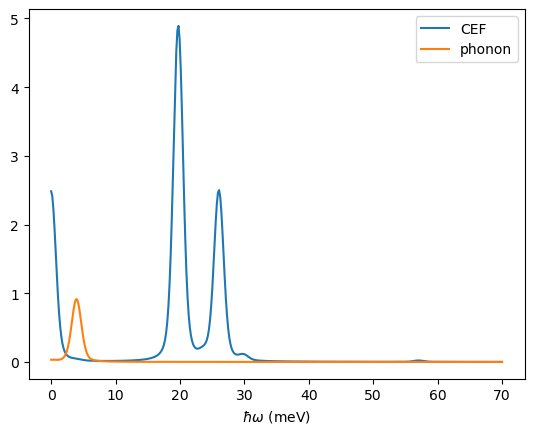

In [5]:
## --- Compute an example spectrum of a phonon from band 3 with wavevector 0,
## gaussian width Gwidth, Lorentzian width Lwidth. 

hbaromega = np.linspace(0,70, 401)
Gwidth, Lwidth = 1.5, 0.5
CEF_nspec_1, PHO_nspec_1 = LYS_dftcef.Compute_NeutronSpectrum(wavevector = 0, 
                                                              band = 3, displacement=1,
                                            hbaromega=hbaromega, Gwidth=Gwidth, Lwidth=Lwidth)

plt.figure()
plt.plot(hbaromega, CEF_nspec_1, label='CEF')
plt.plot(hbaromega, PHO_nspec_1, label='phonon')
plt.xlabel('$\\hbar \\omega$ (meV)')
plt.legend()

## Compute the full Q-dependent spectrum

Try to identify the phonon modes that influence the CEF spectrum most strongly. 

In [6]:
# Define momentum array
nQ = LYS_dftcef.nQ
QQ = np.linspace(0,1, nQ)

## Define array of 2D colormaps
CEF_QEspec = []
PHO_QEspec = []

# Loop through phonon bands
for i in range(LYS_dftcef.nphons):
    CEF_QEspec.append(np.zeros((nQ, len(hbaromega))))
    PHO_QEspec.append(np.zeros((nQ, len(hbaromega))))

    # Loop through wavevectors
    for j in range(nQ):
        CEF_nspec_1, PHO_nspec_1 = LYS_dftcef.Compute_NeutronSpectrum(wavevector = j, band = i, 
                                    displacement=2.5, hbaromega=hbaromega, Gwidth=Gwidth, Lwidth=Lwidth)
        # fill out colormaps Q-point-by-Q-point
        CEF_QEspec[i][j] = CEF_nspec_1
        PHO_QEspec[i][j] = PHO_nspec_1

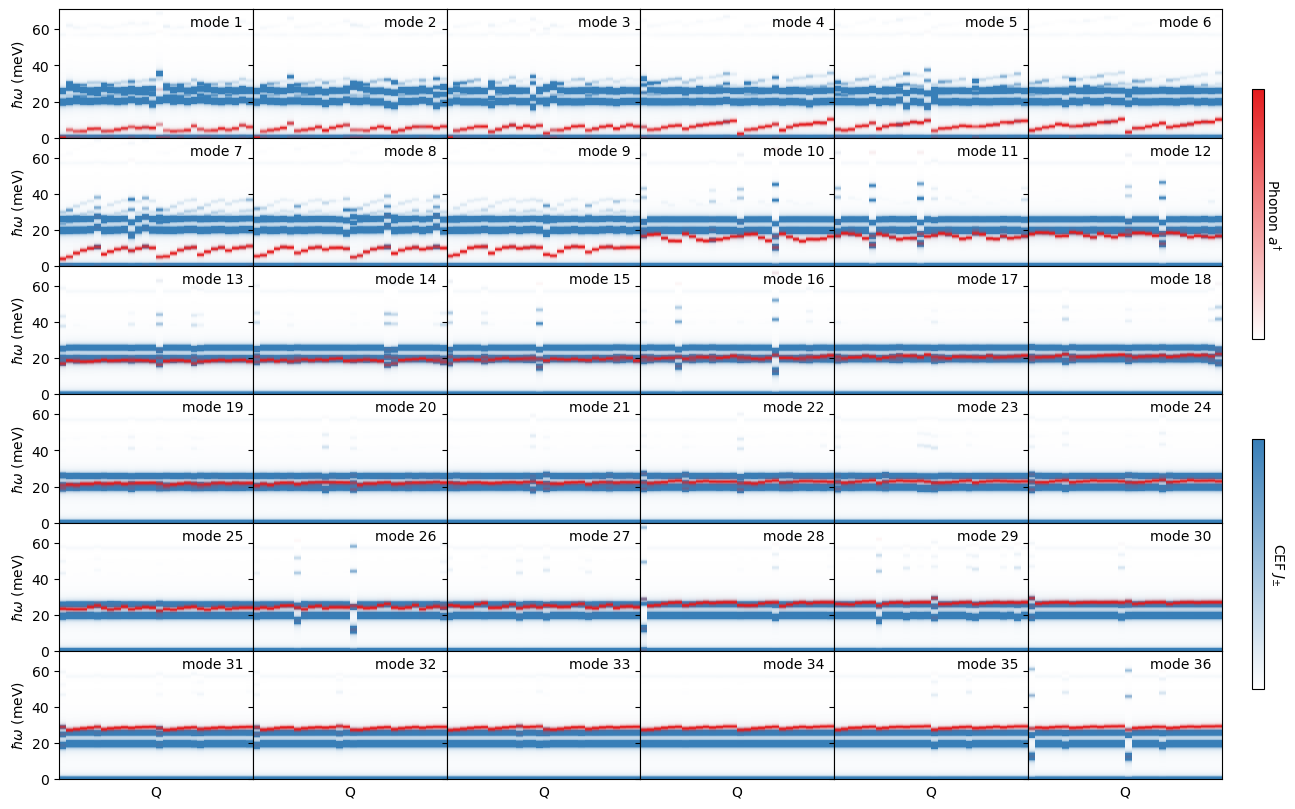

In [7]:
### ------------ Plot the spectrum calculated above ------------------

f,ax = plt.subplots(6,6, figsize=(15,10), sharex=True, sharey=True)
axes=ax.flatten()

for i in range(LYS_dftcef.nphons):
    ## Plot the phonon and CEF spectra as colormaps
    axes[i].pcolormesh(QQ, hbaromega, CEF_QEspec[i].T, 
                       rasterized=True, vmin=0, vmax=0.5, cmap=cef.MyCmp1)
    axes[i].pcolormesh(QQ, hbaromega, PHO_QEspec[i].T, 
                       rasterized=True, vmin=0, cmap=cef.MyCmp0)

    ## The rest of this cell is plot formatting 
    axes[i].text(0.95,0.95, 'mode {}'.format(i+1), va='top', ha='right', 
                 transform=axes[i].transAxes, fontsize=10)
    axes[i].set_ylim(0,71)
    axes[i].set_xticks([])

for i in range(len(ax)):
    ax[i,0].set_ylabel('$\\hbar \\omega$ (meV)')
for i in range(len(ax[0])):
    ax[-1,i].set_xlabel('Q')

f.subplots_adjust(wspace=0.0, hspace=0.0, right=0.9)

##################### Add colormaps 
norm =Normalize(0,1)
cax1 = f.add_axes([0.92,0.2,0.008,0.25])
mappable = plt.cm.ScalarMappable(cmap=cef.MyCmp1, norm = norm)
mappable.set_array([])
cbar = f.colorbar(mappable, cax = cax1, norm=norm, ticks=[])
cbar.set_label('CEF $J_{\\pm}$', 
               labelpad=16, rotation=-90)

cax2 = f.add_axes([0.92,0.55,0.008,0.25])
mappable = plt.cm.ScalarMappable(cmap=cef.MyCmp0, norm = norm)
mappable.set_array([])
cbar2 = f.colorbar(mappable, cax = cax2, norm=norm, ticks=[])
cbar2.set_label('Phonon $a^{\\dagger}$', 
               labelpad=14, rotation=-90)

# Make a toy model 

Select mode 11 at the sixth wavevector to be the representative phonon distortion.

In [ ]:
### ------------- Define phonon distortion operator --------------
j,i = 5,10

Hdistort_0, phE_0 = LYS_dftcef.PhononOperator(wavevector = j, band = i, displacement=0.0001)
## save the CEF parameters of the undistorted mode
# Bs0 = LYS_dftcef.Lig.B
Hdistort_1, phE_1 = LYS_dftcef.PhononOperator(wavevector = j, band = i, displacement=1.0)
## save the CEF parameters of the distorted mode
# Bs = LYS_dftcef.Lig.B

## ------ Phonon distortion operator -------
PhononOO =  Hdistort_0 - Hdistort_1

## ---- If you want to know the Stevens operators of the distortion, run this code ----
# Bs, Bs0 = np.array(Bs).T, np.array(Bs0).T
# DistortBs = (Bs - Bs0).T

In [21]:
Ybfit = deepcopy(Yb)
## Set up the CEF+phonon object 
Yb_CFPH = cef.CEF_Phon_obj(Ybfit, PhononOO)

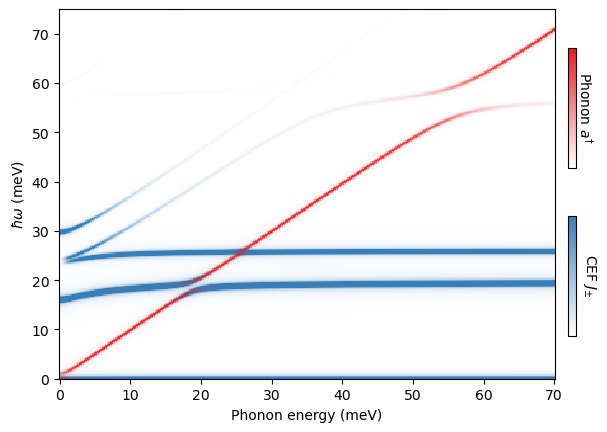

In [ ]:
## Calculate the eigenspectrum
PhononEE = np.linspace(0,70,301)
hbaromega = np.linspace(0,75,301)
Gwidth, Lwidth = 0.5, 0.25
CEF_neutronIntensity = np.zeros((len(PhononEE),len(hbaromega)))
Phonon_neutronIntensity = np.zeros((len(PhononEE),len(hbaromega)))
ResFunc = lambda x: Gwidth

for i in range(len(PhononEE)):

    Yb_CFPH.diagonalize(phononE = PhononEE[i], coupling = 1)

    CEF_neutronIntensity_1 = Yb_CFPH.normalizedCEFNeutronSpectrum(hbaromega, ResFunc, Lwidth)
    PHO_neutronIntensity_1 = Yb_CFPH.PhononNeutronSpectrum(hbaromega, ResFunc, Lwidth)
    
    CEF_neutronIntensity[i] = CEF_neutronIntensity_1
    Phonon_neutronIntensity[i] = PHO_neutronIntensity_1


####### ------------- Plot -------------

f,ax = plt.subplots()
plt.pcolormesh(PhononEE,hbaromega,CEF_neutronIntensity.T, rasterized=True,
               cmap=cef.MyCmp1, vmin=0, vmax=1)
plt.pcolormesh(PhononEE,hbaromega,Phonon_neutronIntensity.T, rasterized=True,
               cmap=cef.MyCmp0)

ax.set_ylim(0,75)
ax.set_xlabel('Phonon energy (meV)')
ax.set_ylabel('$\\hbar \\omega$ (meV)')

##################### ------------- Add colormaps  -------------
norm =Normalize(0,1)
cax1 = f.add_axes([0.92,0.2,0.012,0.25])
mappable = plt.cm.ScalarMappable(cmap=cef.MyCmp1, norm = norm)
mappable.set_array([])
cbar = f.colorbar(mappable, cax = cax1, norm=norm, ticks=[])
cbar.set_label('CEF $J_{\\pm}$', 
               labelpad=16, rotation=-90)

cax2 = f.add_axes([0.92,0.55,0.012,0.25])
mappable = plt.cm.ScalarMappable(cmap=cef.MyCmp0, norm = norm)
mappable.set_array([])
cbar2 = f.colorbar(mappable, cax = cax2, norm=norm, ticks=[])
cbar2.set_label('Phonon $a^{\\dagger}$', 
               labelpad=14, rotation=-90)